# Project Python Foundations: FoodHub Data Analysis

**Marks: 60**

### Context

The number of restaurants in New York is increasing day by day. Lots of students and busy professionals rely on those restaurants due to their hectic lifestyles. Online food delivery service is a great option for them. It provides them with good food from their favorite restaurants. A food aggregator company FoodHub offers access to multiple restaurants through a single smartphone app.

The app allows the restaurants to receive a direct online order from a customer. The app assigns a delivery person from the company to pick up the order after it is confirmed by the restaurant. The delivery person then uses the map to reach the restaurant and waits for the food package. Once the food package is handed over to the delivery person, he/she confirms the pick-up in the app and travels to the customer's location to deliver the food. The delivery person confirms the drop-off in the app after delivering the food package to the customer. The customer can rate the order in the app. The food aggregator earns money by collecting a fixed margin of the delivery order from the restaurants.

### Objective

The food aggregator company has stored the data of the different orders made by the registered customers in their online portal. They want to analyze the data to get a fair idea about the demand of different restaurants which will help them in enhancing their customer experience. Suppose you are hired as a Data Scientist in this company and the Data Science team has shared some of the key questions that need to be answered. Perform the data analysis to find answers to these questions that will help the company to improve the business.

### Data Description

The data contains the different data related to a food order. The detailed data dictionary is given below.

### Data Dictionary

* order_id: Unique ID of the order
* customer_id: ID of the customer who ordered the food
* restaurant_name: Name of the restaurant
* cuisine_type: Cuisine ordered by the customer
* cost: Cost of the order
* day_of_the_week: Indicates whether the order is placed on a weekday or weekend (The weekday is from Monday to Friday and the weekend is Saturday and Sunday)
* rating: Rating given by the customer out of 5
* food_preparation_time: Time (in minutes) taken by the restaurant to prepare the food. This is calculated by taking the difference between the timestamps of the restaurant's order confirmation and the delivery person's pick-up confirmation.
* delivery_time: Time (in minutes) taken by the delivery person to deliver the food package. This is calculated by taking the difference between the timestamps of the delivery person's pick-up confirmation and drop-off information

### Let us start by importing the required libraries

In [1]:
# import libraries for data manipulation
import numpy as np
import pandas as pd

# import libraries for data visualization
import matplotlib.pyplot as plt
import seaborn as sns

### Understanding the structure of the data

In [2]:
# Mounting Google drive in Colab
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# read the data
df = pd.read_csv('/content/drive/MyDrive/foodhub_order.csv')
# returns the first 5 rows
df.head()

,order_id,customer_id,restaurant_name,cuisine_type,cost_of_the_order,day_of_the_week,rating,food_preparation_time,delivery_time
0,1477147,337525,Hangawi,Korean,30.75,Weekend,Not given,25,20
1,1477685,358141,Blue Ribbon Sushi Izakaya,Japanese,12.08,Weekend,Not given,25,23
2,1477070,66393,Cafe Habana,Mexican,12.23,Weekday,5,23,28
3,1477334,106968,Blue Ribbon Fried Chicken,American,29.20,Weekend,3,25,15
4,1478249,76942,Dirty Bird to Go,American,11.59,Weekday,4,25,24


#### Observations:

The DataFrame has 9 columns as mentioned in the Data Dictionary. Data in each row corresponds to the order placed by a customer.

### **Question 1:** How many rows and columns are present in the data? [0.5 mark]

In [4]:
print("There are", df.shape[0], 'rows and', df.shape[1], "columns.")

There are 1898 rows and 9 columns.


#### Observations:
There are 1898 rows and 9 Columns

### **Question 2:** What are the datatypes of the different columns in the dataset? (The info() function can be used) [0.5 mark]

In [5]:
# summary of the DataFrame
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1898 entries, 0 to 1897
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   order_id               1898 non-null   int64  
 1   customer_id            1898 non-null   int64  
 2   restaurant_name        1898 non-null   object 
 3   cuisine_type           1898 non-null   object 
 4   cost_of_the_order      1898 non-null   float64
 5   day_of_the_week        1898 non-null   object 
 6   rating                 1898 non-null   object 
 7   food_preparation_time  1898 non-null   int64  
 8   delivery_time          1898 non-null   int64  
dtypes: float64(1), int64(4), object(4)
memory usage: 133.6+ KB


#### Observations:


*   There are 4 object and 5 numerical datatypes of data in the column
*   The order_id and customer_id should be considered as object datatype since arithmetic calculations of this column will have no insights.
*   The rating should be changed to numerical datatype.



### **Question 3:** Are there any missing values in the data? If yes, treat them using an appropriate method. [1 mark]

In [6]:
#looking for missing values or null values in all columns
df.isnull().sum()

order_id                 0
customer_id              0
restaurant_name          0
cuisine_type             0
cost_of_the_order        0
day_of_the_week          0
rating                   0
food_preparation_time    0
delivery_time            0
dtype: int64

#### Observations:
There are no missing values in the data

In [7]:
#With below code we find what are unique data values in rating column and why was it datatype as object
df['rating'].unique()


array(['Not given', '5', '3', '4'], dtype=object)

There is a value of 'Not given' in rating column.

In [8]:
df['rating'].value_counts()

rating
Not given    736
5            588
4            386
3            188
Name: count, dtype: int64

In [9]:
df['rating'].value_counts(normalize=True)

rating
Not given    0.387777
5            0.309800
4            0.203372
3            0.099052
Name: proportion, dtype: float64

#### Observations:
There are 736 or 39% of data rows that has 'Not given' that needs to be converted to NaN or replaced with mean value of associated restaurant to perform numerical analysis.

Due to high percentage of 'Not given' value, treating with mean value will not be ideal. We will replace with NaN.

In [10]:
df.groupby('day_of_the_week')['rating'].value_counts()

day_of_the_week  rating   
Weekday          Not given    207
                 5            168
                 4            109
                 3             63
Weekend          Not given    529
                 5            420
                 4            277
                 3            125
Name: count, dtype: int64

In [11]:
df[df['rating'] == 'Not given'].groupby(['restaurant_name'])['restaurant_name'].value_counts().nlargest(10)

restaurant_name
Shake Shack                      86
The Meatball Shop                48
Blue Ribbon Sushi                46
Blue Ribbon Fried Chicken        32
Parm                             29
Han Dynasty                      23
Blue Ribbon Sushi Bar & Grill    22
RedFarm Hudson                   21
TAO                              21
Sushi of Gari 46                 20
Name: count, dtype: int64

In [12]:
# replacing 'not given' with nan. This will help to perform arithmetic functions.
df['rating'] = df['rating'].replace(['Not given'],np.nan)

#### Observations:
There are 736 rows of null values after replacing 'not given' and converting to null.

In [13]:
#converting datatype
df['rating']=df['rating'].astype(float)
df['order_id']=df['order_id'].astype(object)
df['customer_id']=df['customer_id'].astype(object)
df['rating'].unique()

array([nan,  5.,  3.,  4.])

In [14]:
df.duplicated().sum()

0

#### Observations:

There are no duplicated values in the rows.

### **Question 4:** Check the statistical summary of the data. What is the minimum, average, and maximum time it takes for food to be prepared once an order is placed? [2 marks]

In [15]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
cost_of_the_order,1898.0,16.498851,7.483812,4.47,12.08,14.14,22.2975,35.41
rating,1162.0,4.344234,0.741478,3.00,4.00,5.00,5.0000,5.00
food_preparation_time,1898.0,27.371970,4.632481,20.00,23.00,27.00,31.0000,35.00
delivery_time,1898.0,24.161749,4.972637,15.00,20.00,25.00,28.0000,33.00


#### Observations:


*  cost_of_the_order: The average cost of the order is 16.50. Minimum cost of order placed was 4.47 and maximum was 35.41
*  rating: The average rating for the order places is 4.3. The minimum and maximum rating received are 3 and 5 respectively. The distribution looks normal.
*  food_preparation_time: The average time taken to prepare food is approximately 27 mins. The minimum and maximum time taken to prepare food was 20 and 35 mins respectively.
* delivery_time: The average delivery time is 24 mins. The minimum time taken for delivery is 15 minutes. The maximum time taken for delivery is 33 minutes




### **Question 5:** How many orders are not rated? [1 mark]

In [16]:
df['rating'].isnull().sum()

736

#### Observations:
There are 736 rows that are not rated.


### Exploratory Data Analysis (EDA)

### Univariate Analysis

### **Question 6:** Explore all the variables and provide observations on their distributions. (Generally, histograms, boxplots, countplots, etc. are used for univariate exploration.) [9 marks]

#### Observations of restaurant name:

In [17]:
df['restaurant_name'].unique()

array(['Hangawi', 'Blue Ribbon Sushi Izakaya', 'Cafe Habana',
       'Blue Ribbon Fried Chicken', 'Dirty Bird to Go',
       'Tamarind TriBeCa', 'The Meatball Shop', 'Barbounia',
       'Anjappar Chettinad', 'Bukhara Grill',
       'Big Wong Restaurant \x8c_¤¾Ñ¼', 'Empanada Mama (closed)', 'Pylos',
       "Lucky's Famous Burgers", 'Shake Shack', 'Sushi of Gari',
       'RedFarm Hudson', 'Blue Ribbon Sushi',
       'Five Guys Burgers and Fries', 'Tortaria', 'Cafe Mogador',
       'Otto Enoteca Pizzeria', 'Vezzo Thin Crust Pizza',
       'Sushi of Gari 46', 'The Kati Roll Company', 'Klong',
       '5 Napkin Burger', 'TAO', 'Parm', 'Sushi Samba',
       'Haru Gramercy Park', 'Chipotle Mexican Grill $1.99 Delivery',
       'RedFarm Broadway', 'Cafeteria', 'DuMont Burger',
       "Sarabeth's East", 'Hill Country Fried Chicken', 'Bistango',
       "Jack's Wife Freda", "Mamoun's Falafel", 'Prosperity Dumpling',
       'Blue Ribbon Sushi Bar & Grill', 'Westville Hudson',
       'Blue Ribbon Br

#### Observations of cuisine type:

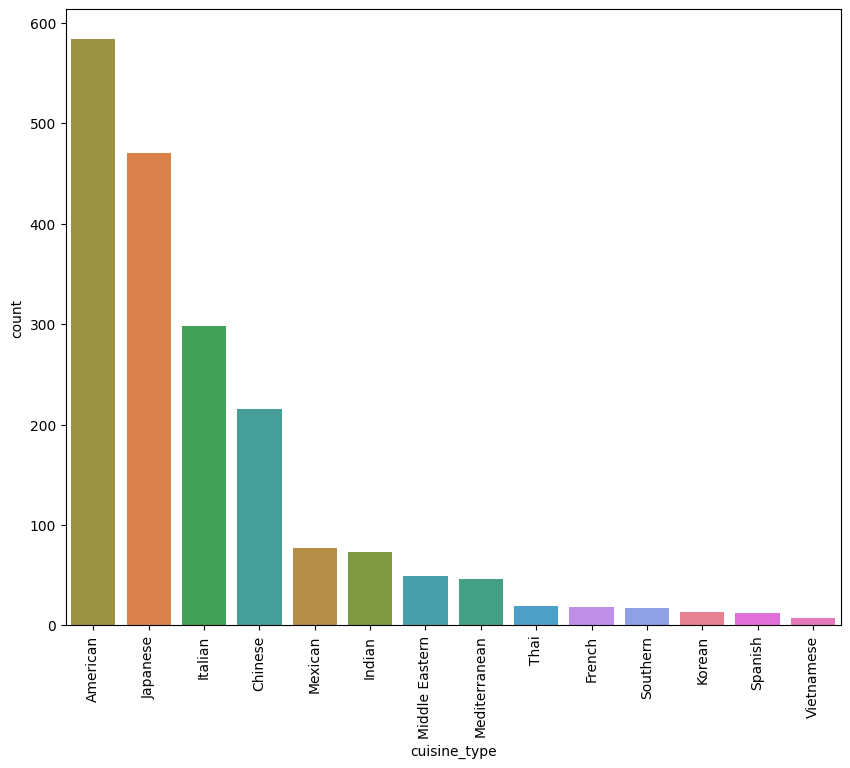

In [18]:
plt.figure(figsize=(10,8))
order1=df['cuisine_type'].value_counts().index
sns.countplot(data=df,x='cuisine_type',order=order1,hue='cuisine_type')
plt.xticks(rotation=90)
plt.show()


American, Japanese, Italian, Chinese are popular cuisines. Vietnamese, spanish and Korean are least popular.

#### Observations of cost:

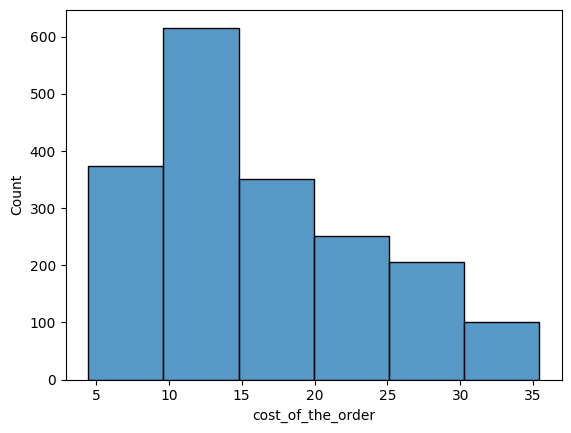

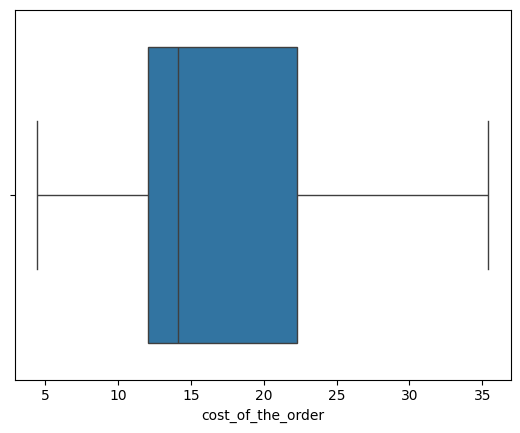

In [19]:
sns.histplot(data=df,x='cost_of_the_order',bins=6)
plt.show()
sns.boxplot(data=df,x='cost_of_the_order')
plt.show()

The most number of order is approx 625 and it cost between 10 and 15 USD. There is a slight right skewness to the distribution.

Bulk of the order placed costs less than 20 USD.

The box plot doesn't show any outliers. The median cost of order is approx 14 USD.


#### Observations of rating:

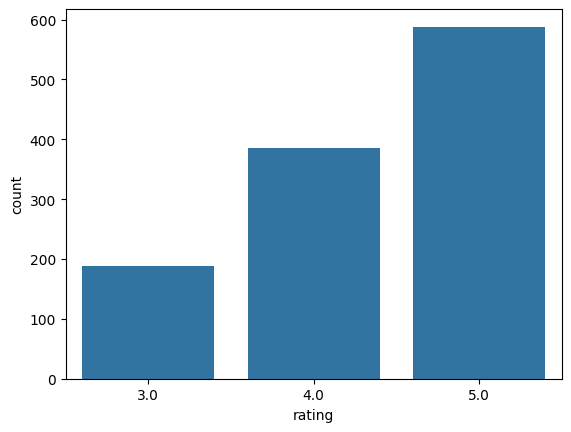

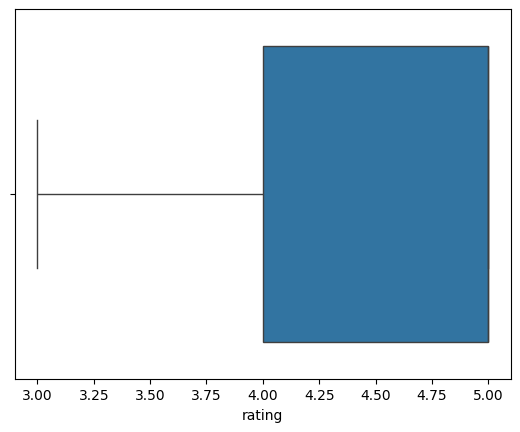

In [20]:
sns.countplot(data=df,x='rating')
plt.show()
sns.boxplot(data=df,x='rating')
plt.show()

The graph shows that distribution is left skewed. More than 500 orders have 5.0 rating of 1162 orders.

Box plot shows there are no outliers. Median line coincides with 5.0

#### Observations of day of the week:

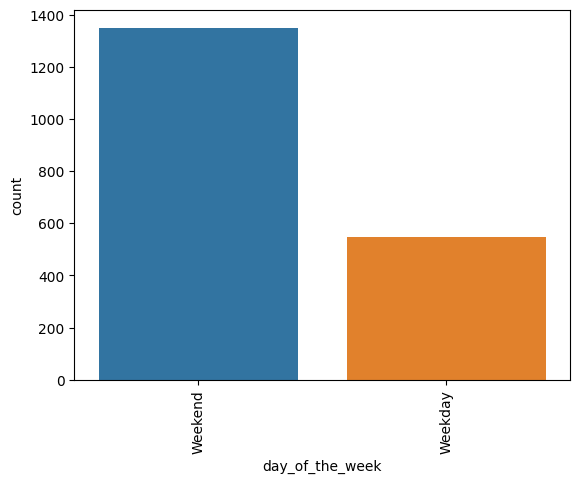

In [21]:
sns.countplot(data=df,x='day_of_the_week',hue='day_of_the_week')
plt.xticks(rotation=90)
plt.show()

Weekend orders are more than double when compared weekday

#### Observations of food preparation time:

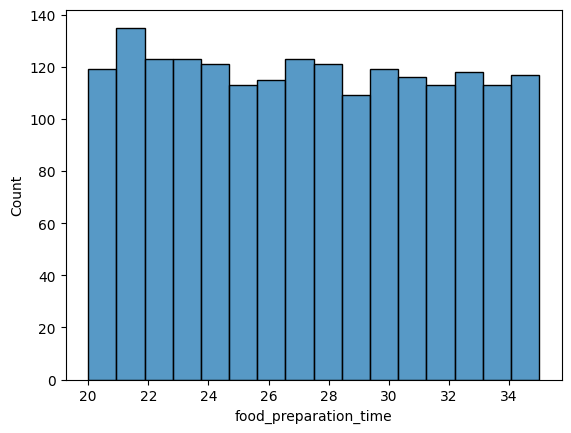

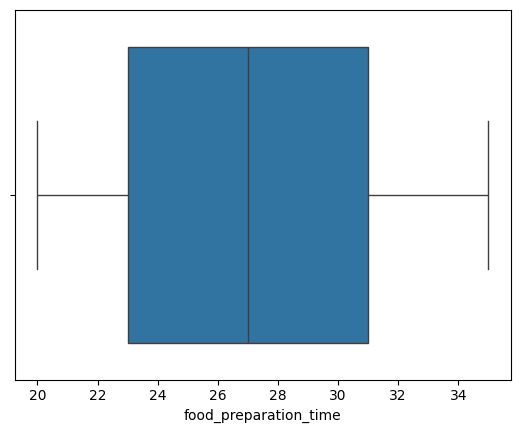

In [22]:
#setting bins to 16. (df.max-df.min)+1 to get interval of 1 min
sns.histplot(data=df,x='food_preparation_time', bins=16)
plt.show()
sns.boxplot(data=df,x='food_preparation_time')
plt.show()

The preparation time is almost equally distributed. No skewness in data

Box plot reveals no outliers.

#### Observations of delivery time:

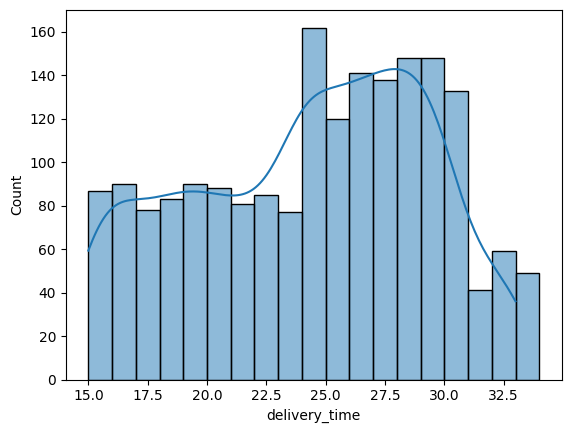

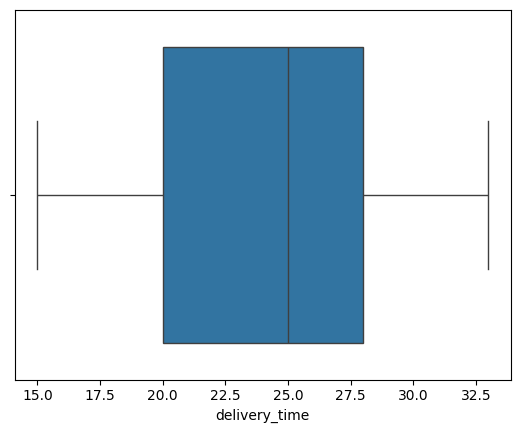

In [23]:
sns.histplot(data=df,x='delivery_time', bins=range(min(df['delivery_time']), max(df['delivery_time'])+2 ,1),kde=True)
plt.show()
sns.boxplot(data=df,x='delivery_time')
plt.show()

Most order were delivered between 24 and 30 minutes. Slight left skewness is evident.

Boxplot has not outliers.

### **Question 7**: Which are the top 5 restaurants in terms of the number of orders received? [1 mark]

In [24]:
df.groupby(['cuisine_type'])['cuisine_type'].value_counts().nlargest(5)

cuisine_type
American    584
Japanese    470
Italian     298
Chinese     215
Mexican      77
Name: count, dtype: int64

The top 5 restaurants are American, Japanese, Italian, Chinese and Mexican.

#### Observations:


### **Question 8**: Which is the most popular cuisine on weekends? [1 mark]

In [25]:
df[df['day_of_the_week']=='Weekend'].groupby(['day_of_the_week'])['cuisine_type'].value_counts().nlargest(1)

day_of_the_week  cuisine_type
Weekend          American        415
Name: count, dtype: int64

#### Observations:
American is most popular cusine of weekends with 415 orders.

### **Question 9**: What percentage of the orders cost more than 20 dollars? [2 marks]

In [26]:
ord_grt_20=df[df['cost_of_the_order'] > 20].shape[0]
total_orders=df['order_id'].shape[0]
perc=np.round((ord_grt_20/total_orders)*100,decimals=2)
print(perc)

29.24


#### Observations:
29.24 percentage of the orders cost more than 20 dollars.

### **Question 10**: What is the mean order delivery time? [1 mark]

In [27]:
df['delivery_time'].mean()

24.161749209694417

#### Observations:
The mean of delivery time is 24 minutes

### **Question 11:** The company has decided to give 20% discount vouchers to the top 3 most frequent customers. Find the IDs of these customers and the number of orders they placed. [1 mark]

In [28]:
df.groupby('customer_id')['order_id'].count().nlargest(3).reset_index(name='total_orders')

,customer_id,total_orders
0,52832,13
1,47440,10
2,83287,9


#### Observations:
The top 3 customers are 52832, 47440 and 83287

### Multivariate Analysis

### **Question 12**: Perform a multivariate analysis to explore relationships between the important variables in the dataset. (It is a good idea to explore relations between numerical variables as well as relations between numerical and categorical variables) [10 marks]


#### Observations of cuisine_type and day_of_the_week :



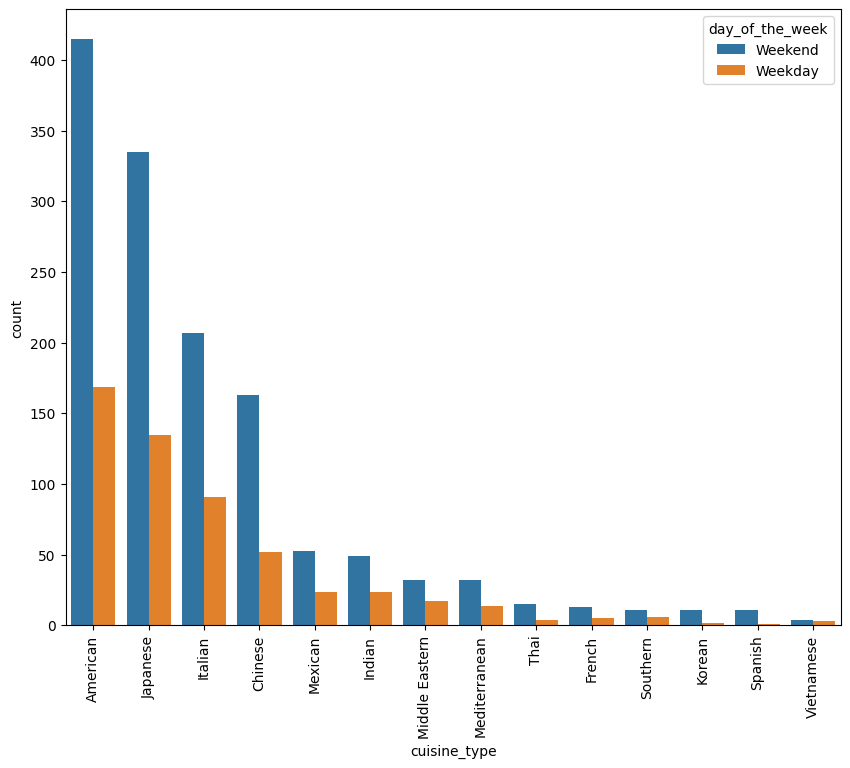

In [29]:
plt.figure(figsize=(10,8))
order1=df['cuisine_type'].value_counts().index
sns.countplot(data=df,x='cuisine_type',order=order1,hue='day_of_the_week')
plt.xticks(rotation=90)
plt.show()

Across all cuisine weekend orders are more than weekdays.

#### Observations between numerical columns with heatmap :

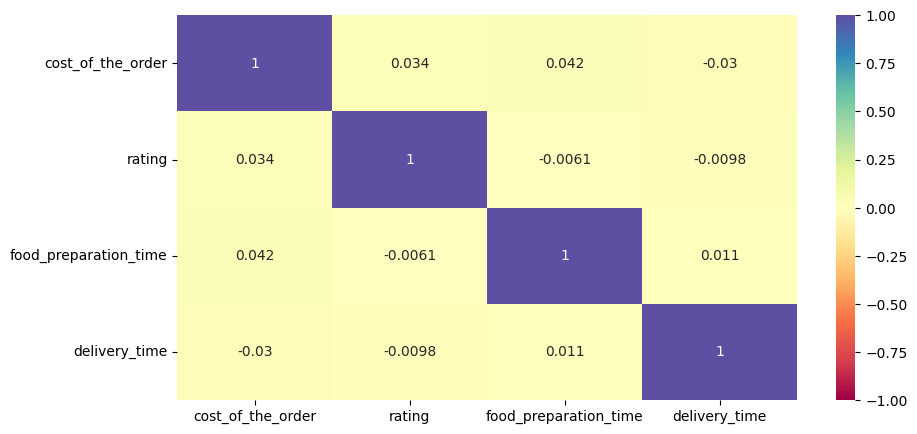

In [30]:
plt.figure(figsize=(10,5))
num_var=['cost_of_the_order', 'rating',
       'food_preparation_time', 'delivery_time']
sns.heatmap(df[num_var].corr(),annot=True,cmap='Spectral',vmin=-1,vmax=1)
plt.show()

There are no strong correlation between numerical features since all of them are closer to zero.

*   ***cost_of_the_order*** has slight positive correlation with *rating and food preparation* time but has slight negative correlation with *delivery_time*.
*   ***rating*** has very slight negative correlation with *food_preparation_time and delivery_time*.
*   ***food_preparation_time and delivery_time*** have slight positive correlation.



Observations between numerical columns with pairplot :

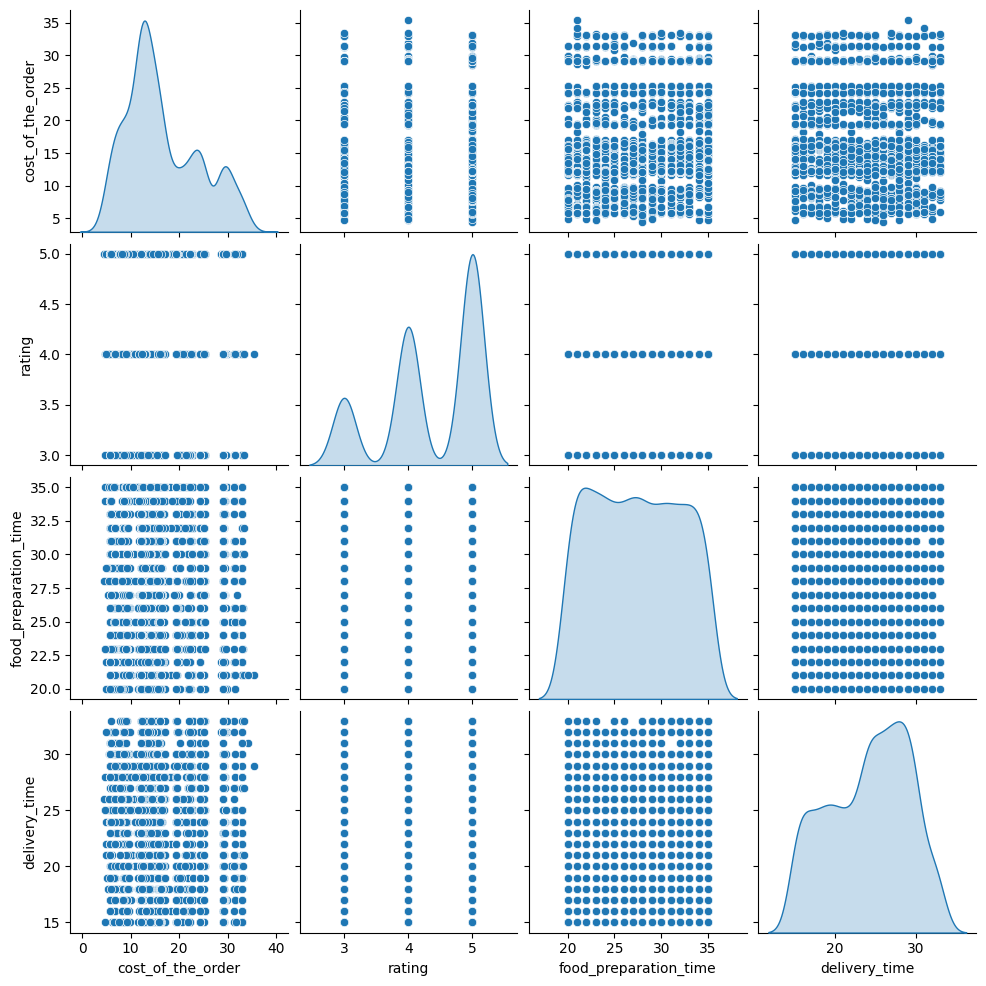

In [31]:
sns.pairplot(data=df[num_var], diag_kind="kde")
plt.show()

There are no correlation and insights that can be derived when comparing and analysing the numerical columns. In the following steps we will take a deeper dive by adding categorical columns.

#### Observations of cuisine_type, cost_of_the_order and day_of_the_week :

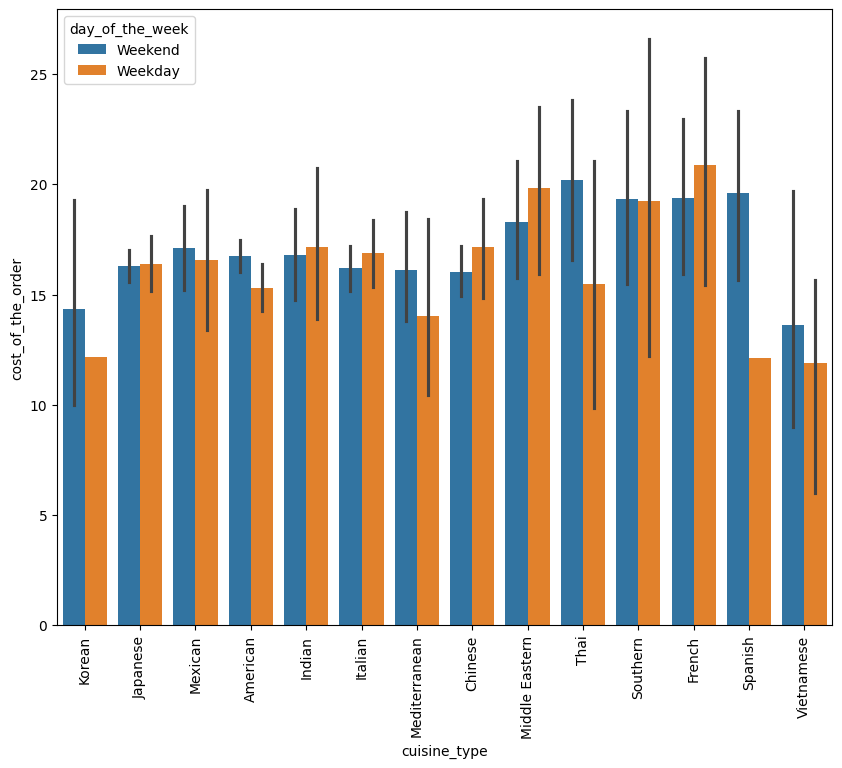

In [32]:
plt.figure(figsize=(10,8))
sns.barplot(data=df,x='cuisine_type',y='cost_of_the_order',hue='day_of_the_week',estimator='mean')
plt.xticks(rotation=90)
plt.show()

*   Most cuisine type's average cost of order varies by few cents when comparing weekdays and weekends.
*   Korean, Mediterranean, Thai, Vietnamese and Spanish has higher weekend mean cost of order.
*   Middle eastern and French higher weekday mean cost of order.



####Observations of cuisine_type, delivery_time and day_of_the_week :

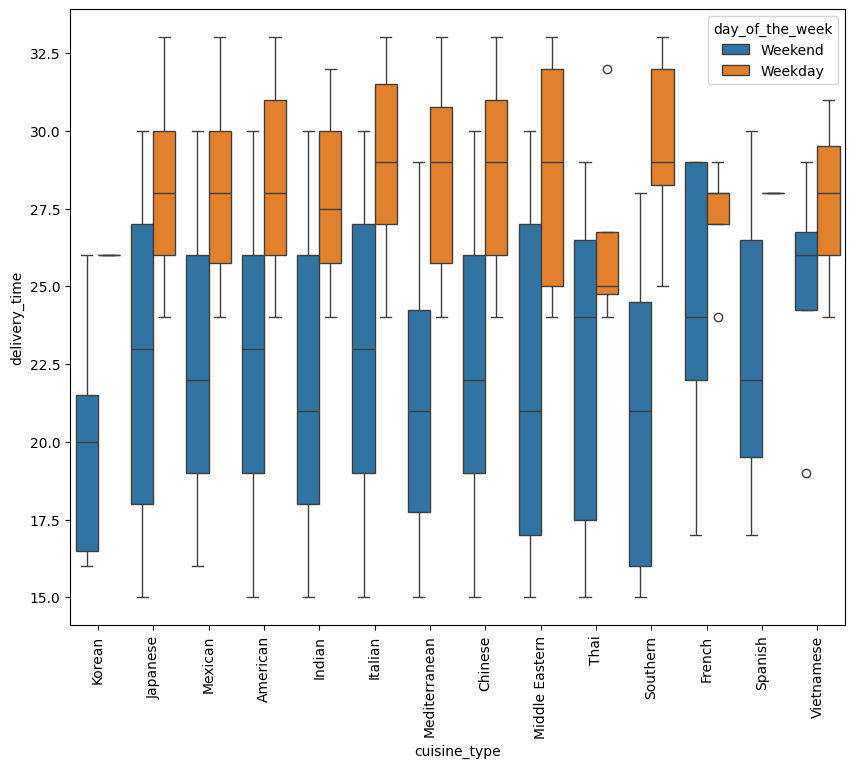

In [33]:
plt.figure(figsize=(10,8))
sns.boxplot(data=df,y='delivery_time',x='cuisine_type',hue='day_of_the_week')
plt.xticks(rotation=90)
plt.show()


*   Weekends have higher delivery time when comapred with weekday
*   Thai cuisine restaurant had an higher delivery time in weekday which was outside of box plot. This outlier needs to be investigated.
*   French cuisine restaurant had an lower delivery time in weekday which was outside of box plot. This outlier needs to be investigated.
*   Vietnamese cuisine restaurant had an lower delivery time in weekend which was outside of box plot. This outlier needs to be investigated.


####Observations of cuisine_type, food_preparation_time and day_of_the_week :

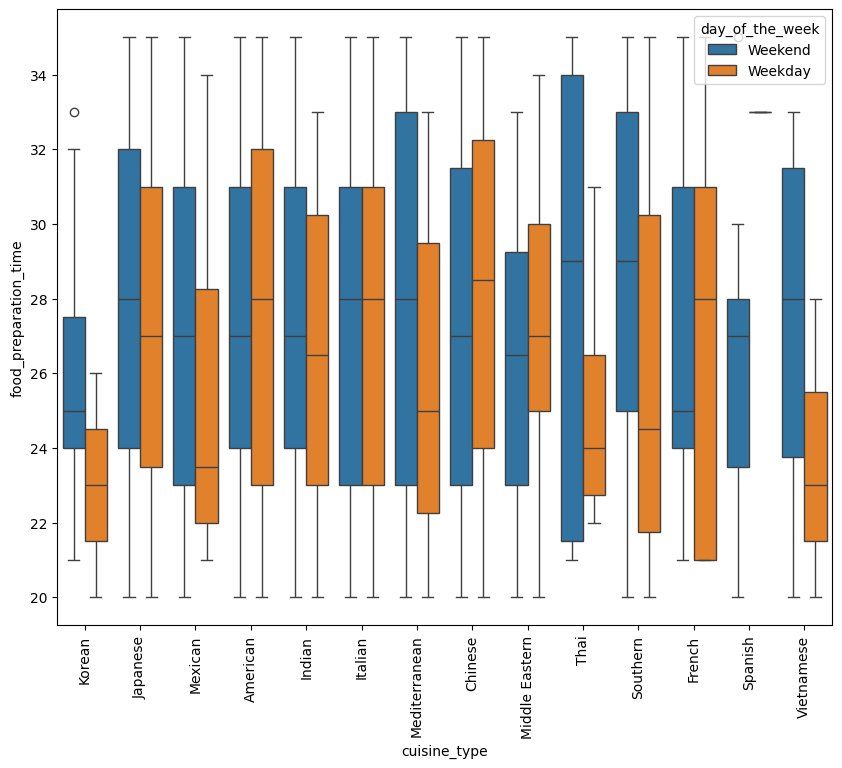

In [34]:
plt.figure(figsize=(10,8))
sns.boxplot(data=df,y='food_preparation_time',x='cuisine_type',hue='day_of_the_week')
plt.xticks(rotation=90)
plt.show()

*   American,Chinese and French cuisine restaurants have higher weekday food preparation time when compared to weekend. This is intriguing since weekend orders are usually higher especially American which is most popular cuisine. I can only speculate that it could be due to particular dishes in the menu that are quicker to prepare are ordered in large quantities. I have no dishes information in the data
*  Mexican, Mediterranean and Thai have significant higher weekend food preparation time when compared with weekday.
*  Italian cuisine food preparation time is same for both weekday and weekend.


#### Observations between rating and cost of the order :

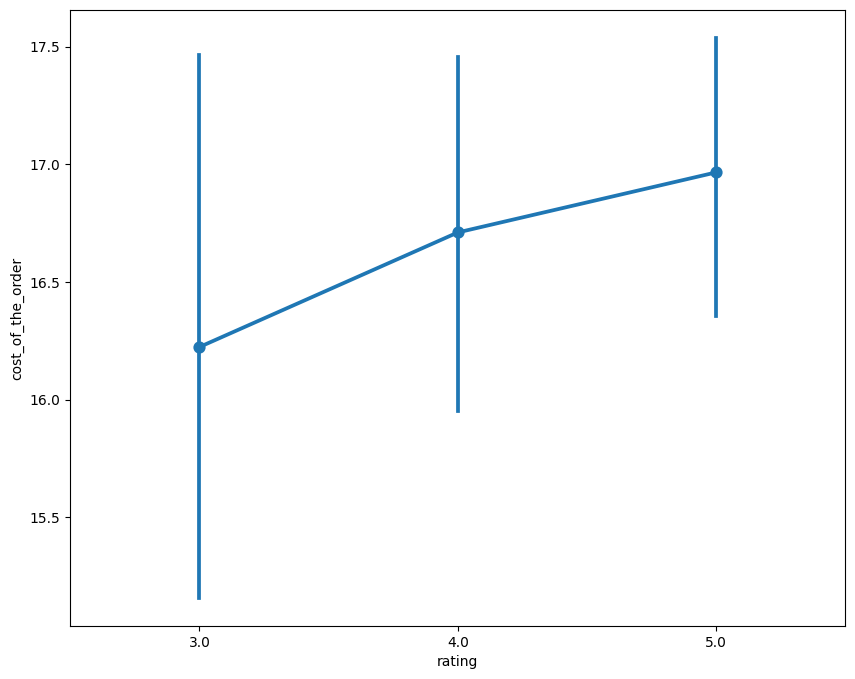

In [35]:
plt.figure(figsize=(10, 8))
sns.pointplot(data=df, x="rating", y="cost_of_the_order")
plt.show()

Ratings and cost of order has slight positive correlation.

#### Observations between rating and food preparation time :

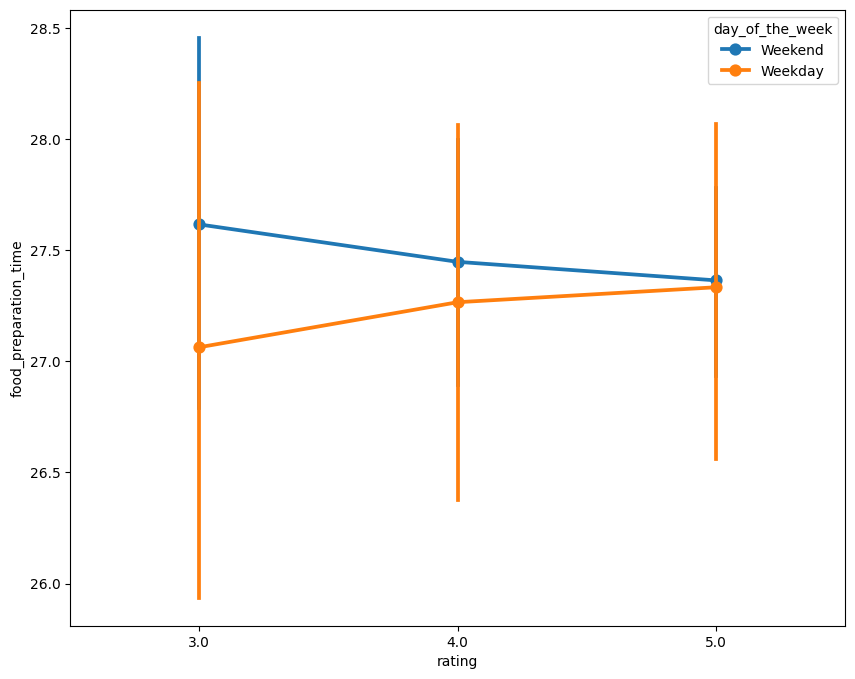

In [36]:
plt.figure(figsize=(10, 8))
sns.pointplot(data=df, x="rating", y="food_preparation_time",  hue='day_of_the_week')
plt.show()

Ratings and food preparation time has slight positive correlation during weekday and slight negative correlation on weekend.

#### Observations between rating and delivery time :

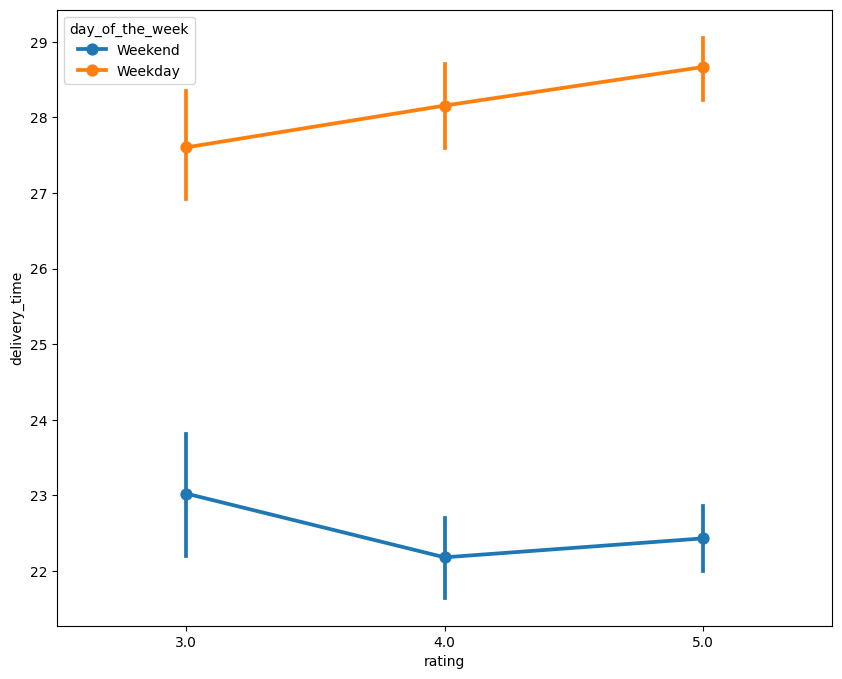

In [37]:
plt.figure(figsize=(10, 8))
sns.pointplot(data=df, x="rating", y="delivery_time",  hue='day_of_the_week')
plt.show()

Ratings and delivery time has positive correlation during weekday and weekend has no linear correlation.

####Observations of restaurant name :

There are 178 restaurants. It is difficult to perform bivariate and multivariate graphical analysis on that many data. So we will not perform it. Instead you are looking top 10 and bottom 10 restaurant names in rating, cost, food preparation time and delivery time.

In [38]:
#finding how many resturants and orders are in different cuisines.

df.groupby(['cuisine_type']).agg({'restaurant_name' : 'nunique', 'order_id' : 'count'}).sort_values(by='restaurant_name',ascending=False).reset_index().rename(columns={'restaurant_name':'no_of_restaurants','order_id':'number_of_orders'})


,cuisine_type,no_of_restaurants,number_of_orders
0,American,41,584
1,Italian,31,298
2,Japanese,29,470
3,Chinese,16,215
4,Indian,14,73
5,Mexican,11,77
6,Thai,9,19
7,Middle Eastern,7,49
8,Korean,5,13
9,Mediterranean,5,46


In [39]:
#top 10 restaurant in order quantity
df['restaurant_name'].value_counts().nlargest(10).reset_index(name='count')

,restaurant_name,count
0,Shake Shack,219
1,The Meatball Shop,132
2,Blue Ribbon Sushi,119
3,Blue Ribbon Fried Chicken,96
4,Parm,68
5,RedFarm Broadway,59
6,RedFarm Hudson,55
7,TAO,49
8,Han Dynasty,46
9,Blue Ribbon Sushi Bar & Grill,44


In [40]:
#top 10 highly rated restaurants
df[df['rating'] ==5.0].groupby(['restaurant_name'])['restaurant_name'].value_counts().nlargest(10).reset_index(name='count')

,restaurant_name,count
0,Shake Shack,60
1,The Meatball Shop,53
2,Blue Ribbon Fried Chicken,32
3,Blue Ribbon Sushi,32
4,RedFarm Broadway,18
5,Blue Ribbon Sushi Bar & Grill,15
6,RedFarm Hudson,15
7,Parm,14
8,Han Dynasty,13
9,TAO,13


In [41]:
#top 10 restaurants in revenue
df.groupby(['restaurant_name'])['cost_of_the_order'].sum().nlargest(10).reset_index(name='Total Sales')

,restaurant_name,Total Sales
0,Shake Shack,3579.53
1,The Meatball Shop,2145.21
2,Blue Ribbon Sushi,1903.95
3,Blue Ribbon Fried Chicken,1662.29
4,Parm,1112.76
5,RedFarm Broadway,965.13
6,RedFarm Hudson,921.21
7,TAO,834.50
8,Han Dynasty,755.29
9,Blue Ribbon Sushi Bar & Grill,666.62


In [42]:
#bottom 10 restaurants in revenue
df.groupby(['restaurant_name'])['cost_of_the_order'].sum().sort_values(ascending=False).tail(10).reset_index(name='Total Sales')

,restaurant_name,Total Sales
0,Gaia Italian Cafe,8.78
1,Chola Eclectic Indian Cuisine,8.73
2,Woorijip,8.25
3,'wichcraft,8.10
4,La Follia,8.05
5,Market Table,6.79
6,Wa Jeal,6.74
7,Cipriani Le Specialita,5.92
8,Big Wong Restaurant _¤¾Ñ¼,5.92
9,Hunan Manor,5.72


In [43]:
#Slowest 10 restaurants in delivery time
df.groupby(['restaurant_name'])['delivery_time'].mean().nlargest(10).reset_index(name='Mean_delivery_time')

,restaurant_name,Mean_delivery_time
0,Sarabeth's West,33.0
1,Haru Gramercy Park,32.0
2,Taro Sushi,32.0
3,Frank Restaurant,31.0
4,Haandi,30.5
5,Carmine's,30.0
6,Chote Nawab,30.0
7,Cipriani Le Specialita,30.0
8,Crema Restaurante,30.0
9,Dos Caminos Soho,30.0


In [44]:
#Quickest 10 restaurants in delivery time
df.groupby(['restaurant_name'])['delivery_time'].mean().nsmallest(10).reset_index(name='Mean_delivery_time')

,restaurant_name,Mean_delivery_time
0,Gaia Italian Cafe,15.0
1,Hibino,15.0
2,Paul & Jimmy's,15.0
3,The MasalaWala,15.0
4,Coppola's East,16.0
5,Galli Restaurant,16.0
6,Wo Hop Restaurant,16.0
7,Market Table,17.0
8,Byblos Restaurant,18.0
9,Samurai Mama,18.0


In [45]:
#Slowest 10 restaurants in preparation time
df.groupby(['restaurant_name'])['food_preparation_time'].mean().nlargest(10).reset_index(name='Mean_prep_time')

,restaurant_name,Mean_prep_time
0,Cipriani Le Specialita,35.0
1,Kambi Ramen House,35.0
2,Klong,35.0
3,Sushi Choshi,35.0
4,Taro Sushi,35.0
5,Alidoro,34.0
6,Big Wong Restaurant _¤¾Ñ¼,34.0
7,Il Bambino,34.0
8,Spice Thai,34.0
9,Hot Kitchen,33.0


In [46]:
#Quickest 10 restaurants in preparation time
df.groupby(['restaurant_name'])['food_preparation_time'].mean().nsmallest(10).reset_index(name='Mean_prep_time')

,restaurant_name,Mean_prep_time
0,67 Burger,20.0
1,Frank Restaurant,20.0
2,Haru Gramercy Park,20.0
3,DespaÌ±a,20.5
4,Anjappar Chettinad,21.0
5,Hampton Chutney Co.,21.0
6,Lucky Strike,21.0
7,Market Table,21.0
8,Samurai Mama,21.0
9,Sarabeth's West,21.0


### **Question 13:** The company wants to provide a promotional offer in the advertisement of the restaurants. The condition to get the offer is that the restaurants must have a rating count of more than 50 and the average rating should be greater than 4. Find the restaurants fulfilling the criteria to get the promotional offer. [3 marks]

In [47]:
#below code identifies restaurants and their ratings. We exclude ratings that are null and store in a dataframe
df_rest_count=df[df['rating'].notna()].groupby(['restaurant_name'])['restaurant_name'].value_counts().sort_values(ascending=False).reset_index(name='count')
print(df_rest_count)


               restaurant_name  count
0                  Shake Shack    133
1            The Meatball Shop     84
2            Blue Ribbon Sushi     73
3    Blue Ribbon Fried Chicken     64
4             RedFarm Broadway     41
..                         ...    ...
151           Frank Restaurant      1
152        Socarrat Paella Bar      1
153            El Parador Cafe      1
154               Lucky Strike      1
155                 'wichcraft      1

[156 rows x 2 columns]


In [48]:
#finding restaurants that have more than 50 ratings and assign as a list
rest_name_50=df_rest_count.loc[df_rest_count['count'] > 50]['restaurant_name'].tolist()
print(rest_name_50)

['Shake Shack', 'The Meatball Shop', 'Blue Ribbon Sushi', 'Blue Ribbon Fried Chicken']


In [49]:
#we create a dataframe to store restaurant names and their mean values
mean4_df=df[df['restaurant_name'].isin( rest_name_50 )].groupby(['restaurant_name'])['rating'].mean().reset_index(name='mean_avg')
print(mean4_df)


             restaurant_name  mean_avg
0  Blue Ribbon Fried Chicken  4.328125
1          Blue Ribbon Sushi  4.219178
2                Shake Shack  4.278195
3          The Meatball Shop  4.511905


In [50]:
#below code displays restaurant name that are have greater than 4.0 mean rating
print( "The restaurants that have 50 ratings and mean ratng of more than 4 are", mean4_df[mean4_df['mean_avg'] > 4.0]['restaurant_name'].to_list())

The restaurants that have 50 ratings and mean ratng of more than 4 are ['Blue Ribbon Fried Chicken', 'Blue Ribbon Sushi', 'Shake Shack', 'The Meatball Shop']


#### Observations:
The restaurants that fulfill the criteria are **'Blue Ribbon Fried Chicken', 'Blue Ribbon Sushi', 'Shake Shack', 'The Meatball Shop'**

### **Question 14:** The company charges the restaurant 25% on the orders having cost greater than 20 dollars and 15% on the orders having cost greater than 5 dollars. Find the net revenue generated by the company across all orders. [3 marks]

In [51]:
#calculating the restaurant 25% on the orders having cost greater than 20 dollars and assigning to a variable
cost_20=(df[df['cost_of_the_order']  > 20.00]['cost_of_the_order'].sum() * .25)
#calculating the 15% on the orders having cost greater than 5 dollars and assigning to a variable
cost_5=(df[(df['cost_of_the_order']  > 5.00) & (df['cost_of_the_order']  <= 20.00) ]['cost_of_the_order'].sum() * .15)
#summing the variable to find total
print("$",np.round(cost_20 + cost_5 , decimals=2))

$ 6166.3


#### Observations:
$6166.30 is the net revenue generated by the company across all orders

### **Question 15:** The company wants to analyze the total time required to deliver the food. What percentage of orders take more than 60 minutes to get delivered from the time the order is placed? (The food has to be prepared and then delivered.) [2 marks]

In [52]:
#total time is calculated by summing delivery and preparation time
df['total_time'] = df['delivery_time']+df['food_preparation_time']
#calculating percentage of orders taking more than 60 minutes
print("The percentage of orders take more than 60 minutes to get delivered from the time the order is placed", np.round(df[df['total_time'] > 60]['order_id'].count() * 100/df.shape[0],decimals=2),"%")


The percentage of orders take more than 60 minutes to get delivered from the time the order is placed 10.54 %


#### Observations:
The percentage of orders take more than 60 minutes to get delivered from the time the order is placed 10.54 %

### **Question 16:** The company wants to analyze the delivery time of the orders on weekdays and weekends. How does the mean delivery time vary during weekdays and weekends? [2 marks]

In [53]:
df.groupby(['day_of_the_week'])['delivery_time'].mean().round(2).reset_index(name='mean')

,day_of_the_week,mean
0,Weekday,28.34
1,Weekend,22.47


#### Observations:
Mean delivery time indicates that weekday delivery time takes more than weekend. This could be due to higher number of orders placed on the weekend which brings more number of delivery drivers. We cannot perform that analysis due to lack of pickup data such as drivers,location and time etc.

### Conclusion and Recommendations

### **Question 17:** What are your conclusions from the analysis? What recommendations would you like to share to help improve the business? (You can use cuisine type and feedback ratings to drive your business recommendations.) [6 marks]

In [54]:
df[df['total_time'] > 60]['rating'].value_counts()

rating
5.0    61
4.0    39
3.0    19
Name: count, dtype: int64

Company had a question to find percentage of orders that have total time more than 60 minutes. When taking a look at the rating we can see it doesn't affect much. We have 61 ratings of 5 in 119 documented ratings for orders with more than 60 mins time.

### Conclusions:
1. American is the most popular cuisine and shake shack is the most popular restaurant.
2. Of 14 cuisines, Top 4 contribute more than contribute more than 80% of orders.
3. Weekend orders are popular across all restaurants. People like to be at home and get order delivered to their place. Even though 10% of orders take more than 60 minutes from time of order placed to deliver.
4. Even when weekend orders are high it doesn't affect delivery time. It is 6 minutes quicker than average time taken to deliver during weekday.
5. Ratings have very slight correlation with cost, delivery time and food preparation time.
6. We have more than 39% of customers have not given rating. Need to investigate why these customers didn't participate in rating.
7. Orders cost more than $20 generates more revenue but its just one third in order volume.

### Recommendations:

1.  Japanese, Italian and Chinese are next popular to American. They show potential.
2. Weekday delivery time needs to improve. Need to ensure delivery drivers availability.
3. Premium restaurants or restaurants with orders more than $20 generate more revenue. Expansion in these restaurants and dish offerings directly impact revenue.
4. Italian cuisines have average food preparation time taken to be same for weekend and weekday. Best practices from this cuisine can be applied across company.
5. Impact of rating for a business is crucial. Current generic rating is less useful with 39% of orders have 'not given' ratings. Customer participation needs to be improved and make them feel cared. To create a meaningful impact I suggest to create ratings for each cost, delivery time, delivery person care and demeanor.
6. I strongly recommend to include location of restaurants, location of drop off and date/time of order/drop so that a model can be in place to better serve company.

---